✅ Catálogo localizado en el entorno virtual: /home/jacl/github/Blind_deconvolution_astronomy/.venv/lib/python3.11/site-packages/galsim/share/COSMOS_23.5_training_sample
📦 Catálogo cargado con éxito. Total de galaxias: 50932


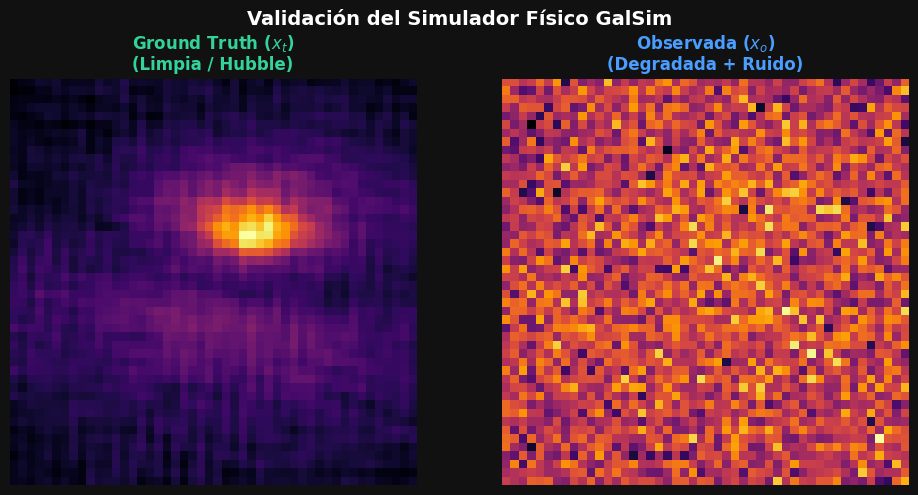

In [ ]:
# 1. Activamos la extensión de auto-recarga de módulos
%load_ext autoreload
%autoreload 2

# 2. Comando mágico indispensable para los gráficos
%matplotlib inline

import os
import sys
import matplotlib.pyplot as plt
import galsim

# El resto de tu código de prueba se queda exactamente igual...
PROJECT_ROOT = "/home/jacl/github/Blind_deconvolution_astronomy"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.image_simulator import generate_pair, catalog_file, pixel_scale
from src.psf_generator import generate_combined_psf

# Definimos la ruta del .venv que encontramos antes
catalog_dir_final = "/home/jacl/github/Blind_deconvolution_astronomy/.venv/lib/python3.11/site-packages/galsim/share/COSMOS_23.5_training_sample"

# Cargar y simular
catalog = galsim.COSMOSCatalog(file_name=catalog_file, dir=catalog_dir_final)
psf_array, _ = generate_combined_psf(image_size=48, pixel_scale=pixel_scale)

# Probamos con otra galaxia aleatoria para ver el cambio (ejemplo: index=12)
x_t, x_o = generate_pair(catalog, index=12, psf_array=psf_array, psf_scale=pixel_scale)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(10, 5), facecolor='#111111')
axes[0].imshow(x_t, cmap='inferno', vmin=-1, vmax=1)
axes[0].set_title("Ground Truth ($x_t$)\n(Limpia / Hubble)", color='#34d399', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(x_o, cmap='inferno', vmin=-1, vmax=1)
axes[1].set_title("Observada ($x_o$)\n(Degradada + Ruido Realista)", color='#4a9eff', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Validación del Simulador Físico GalSim (CORREGIDO)", color='white', fontsize=14, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()